# Portfolio risk as a quadratic form
**Why Markowitz fails, and how Σ's eigenstructure explains it** — Advanced Linear Algebra, Module 2.

Portfolio variance is the quadratic form $w^\top \Sigma w$. With $\Sigma = Q\Lambda Q^\top$ and $y = Q^\top w$ it has the **normal form** $\sum_i \lambda_i y_i^2$. The min-variance weights $w \propto \Sigma^{-1}\mathbf 1 = \sum_i \lambda_i^{-1} q_i (q_i^\top \mathbf 1)$ amplify the *smallest* eigenvalues, which are the noisiest. This notebook is thin: all linear algebra lives in `src/linalg_tools.py`; every number shown is computed when the notebook runs.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown
from src import config, data, covariance as cv, linalg_tools as lt, optimize as op, evaluate, plots, diagnostics
pd.set_option('display.width', 200, 'display.max_columns', 30)
returns, returns_nan, dropped = data.get_returns()
print(f'{returns.shape[0]} days x {returns.shape[1]} stocks, {returns.index[0]:%Y-%m-%d} to {returns.index[-1]:%Y-%m-%d}; dropped: {dropped or "none"}')

1238 days x 30 stocks, 2021-10-11 to 2026-10-06; dropped: none


## 1. Eigenstructure of the full-sample Σ
Inertia (signature), definiteness, conditioning.

In [2]:
full = diagnostics.full_sample_report(returns)
pd.Series(full).to_frame('value')

,value
T,1238
N,30
lambda_min,0.000058
lambda_median,0.000123
lambda_max,0.002074
top1_variance_share,0.299165
inertia,"(30, 0, 0)"
condition_number,35.611162
positive_definite,True
mp_edge,0.000309


## 2. Sylvester's law of inertia
Under a congruence $\Sigma \mapsto P^\top \Sigma P$ with invertible $P$ the eigenvalues change but the *counts* of positive/zero/negative eigenvalues do not. We check this on (a) the real Σ, (b) a constructed **indefinite** matrix $\Sigma - cI$ (shifted so exactly three eigenvalues go negative), and (c) a **singular** short-window covariance.

In [3]:
S = cv.sample_cov(returns)
vals, _ = lt.eig_decompose(S)
c = 0.5 * (vals[2] + vals[3])
S_ind = S - c * np.eye(len(S))
S_sing, _ = cv.short_window_cov(returns, T=20)
rows = []
for name, M_ in [('sample Σ', S), ('indefinite Σ - cI', S_ind), ('singular (T=20)', S_sing)]:
    ok = [lt.verify_sylvester(M_, seed=s)[0] for s in range(25)]
    _, i0, i1 = lt.verify_sylvester(M_, seed=0)
    ev_after = np.linalg.eigvalsh(lt.random_invertible(len(M_), np.random.default_rng(0)).T @ M_ @ lt.random_invertible(len(M_), np.random.default_rng(0)))
    rows.append(dict(matrix=name, inertia=i0, inertia_after_PtSP=i1, holds_in_25_random_P=all(ok),
                     lambda_min_before=np.linalg.eigvalsh(M_)[0], lambda_min_after=ev_after[0]))
pd.DataFrame(rows)

,matrix,inertia,inertia_after_PtSP,holds_in_25_random_P,lambda_min_before,lambda_min_after
0,sample Σ,"(30, 0, 0)","(30, 0, 0)",True,5.823760e-05,1.030025e-08
1,indefinite Σ - cI,"(27, 0, 3)","(27, 0, 3)",True,-1.605279e-05,-2.157527e-04
2,singular (T=20),"(19, 11, 0)","(19, 11, 0)",True,-1.725266e-19,-5.606522e-18


## 3. Normal form and risk decomposition
Risk of the raw min-variance portfolio on the demo training window, split by principal direction: $c_i = \lambda_i y_i^2$, $\sum_i c_i = w^\top\Sigma w$ (asserted inside `normal_form_transform`).

In [4]:
train, test = plots.demo_window(returns)
S_w = cv.sample_cov(train)
w = lt.min_variance_weights_spectral(S_w)
print('spectral weights == solve:', np.allclose(w, op.min_variance_closed_form(S_w)))
y, contrib = lt.normal_form_transform(S_w, w)
vals_w, _ = lt.eig_decompose(S_w)
tbl = pd.DataFrame({'direction (1=smallest)': np.arange(1, len(vals_w)+1), 'eigenvalue': vals_w, 'y_i': y, 'risk share %': 100*contrib/contrib.sum()})
print(f'window {train.index[0]:%Y-%m-%d} to {train.index[-1]:%Y-%m-%d}; w\'Sw = {w@S_w@w:.3e} = sum(c_i) = {contrib.sum():.3e}')
print('noise exposure score for k in', config.BOTTOM_K, [round(lt.noise_exposure_score(S_w, w, k), 3) for k in config.BOTTOM_K])
tbl.head(8)

spectral weights == solve: True
window 2026-02-20 to 2026-05-21; w'Sw = 1.848e-05 = sum(c_i) = 1.848e-05
noise exposure score for k in [1, 3, 5] [0.418, 0.62, 0.729]


,direction (1=smallest),eigenvalue,y_i,risk share %
0,1,0.000010,-0.453650,11.627361
1,2,0.000019,-0.296826,9.231747
2,3,0.000021,-0.105701,1.297958
3,4,0.000024,-0.229854,6.768103
4,5,0.000031,-0.028667,0.137722
5,6,0.000033,-0.009929,0.017673
6,7,0.000037,-0.092277,1.713449
7,8,0.000043,-0.214791,10.642163


## 4. Broken Σ: short windows and missing data

In [5]:
short = diagnostics.short_window_report(returns)
short

,T,N,n_pos,n_zero,n_neg,pd_cholesky,cond,solve_ok,max_abs_w_solve,max_abs_w_spectral
0,15,30,14,16,0,False,inf,True,1.762727,0.214834
1,29,30,28,2,0,False,inf,True,8.724588,0.361829
2,30,30,29,1,0,False,4.374516e+16,True,28.968171,0.365020
3,31,30,30,0,0,True,8.067999e+04,True,0.369425,0.369425
4,60,30,30,0,0,True,1.605616e+02,True,0.317613,0.317613
5,90,30,30,0,0,True,1.262559e+02,True,0.258280,0.258280
6,120,30,30,0,0,True,1.026190e+02,True,0.354353,0.354353
7,250,30,30,0,0,True,6.955997e+01,True,0.277621,0.277621
8,500,30,30,0,0,True,4.293908e+01,True,0.169313,0.169313
9,750,30,30,0,0,True,4.189619e+01,True,0.141878,0.141878


In [6]:
missing = cv.missing_data_scenarios(returns)
missing.groupby('mask_frac').agg(runs=('seed','size'), non_psd=('non_psd','sum'), lambda_min_min=('lambda_min','min'), max_n_neg=('n_neg','max'))

,runs,non_psd,lambda_min_min,max_n_neg
mask_frac,,,,
0.05,20,0,0.000054,0
0.10,20,0,0.000049,0
0.20,20,0,0.000041,0


Reading the two tables: with $T \le N$ the sample covariance is exactly singular (rank $T-1$, so $N-T+1$ zero eigenvalues); `np.linalg.solve` may nevertheless return weights, whereas inertia reports the singularity unambiguously. With random missingness and this many observations, the pairwise-complete covariance stayed positive definite in our runs — we report that as measured.

## 5. Rolling out-of-sample backtest
6 window lengths × 4 covariance estimators × 2 optimizers; train on $W$ days, evaluate on the next 60.

In [7]:
runs = evaluate.run_backtest(returns)
tables = evaluate.save_results(runs)
summary = tables['summary_table']
print(len(runs), 'runs')
(summary[summary.constraint=='unconstrained']
   .pivot(index='window', columns='method', values='risk_gap_mean')[list(config.METHODS)] * 100).round(2)

736 runs


method,raw,clipped,mp,ledoit_wolf
window,,,,
60,8.30,6.42,4.13,3.78
90,5.14,4.99,3.54,3.15
120,3.70,3.68,3.04,2.41
250,1.34,1.34,1.96,1.17
500,1.29,1.29,2.40,1.35
750,1.03,1.03,2.17,1.08


In [8]:
# Mean realised risk (annualised %), long-only vs unconstrained
(summary.pivot_table(index=['constraint','window'], columns='method', values='realized_risk_mean')[list(config.METHODS)] * 100).round(2)

method                  raw  clipped     mp  ledoit_wolf
constraint    window                                    
long_only     60      11.71    11.70  11.45        11.37
              90      11.49    11.49  11.35        11.20
              120     11.18    11.18  11.05        10.94
              250     10.43    10.43  10.50        10.36
              500     11.23    11.23  11.56        11.20
              750     11.23    11.23  11.65        11.21
unconstrained 60      15.12    13.63  11.69        11.66
              90      12.99    12.88  11.53        11.42
              120     12.28    12.26  11.36        11.14
              250     10.71    10.71  10.70        10.45
              500     11.10    11.10  11.46        11.05
              750     11.11    11.11  11.59        11.07

## 6. Figures

**fig1_eigenvalue_spectrum.png**

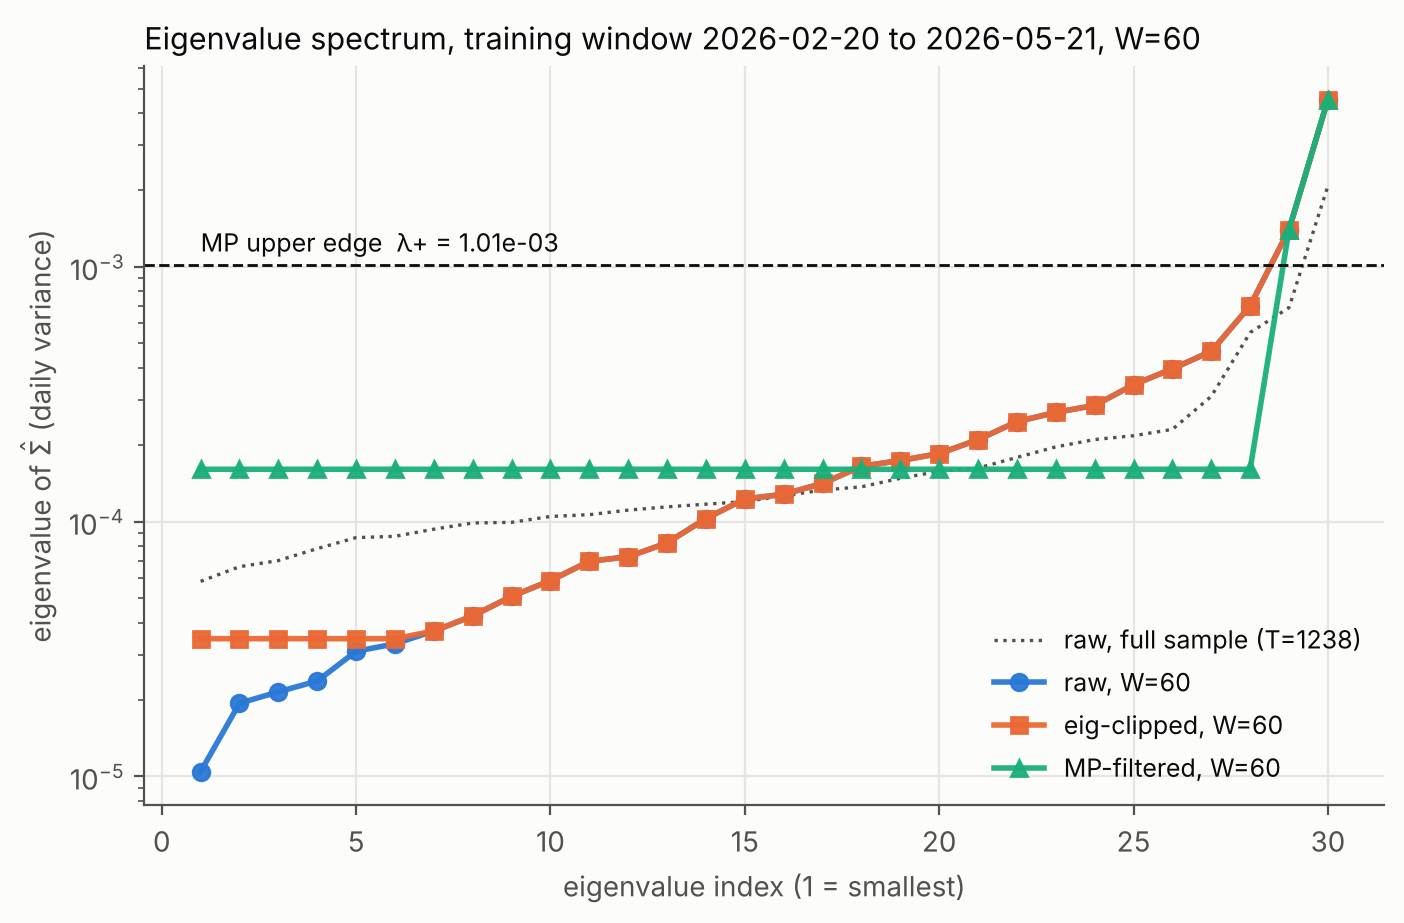

**fig2_efficient_frontier.png**

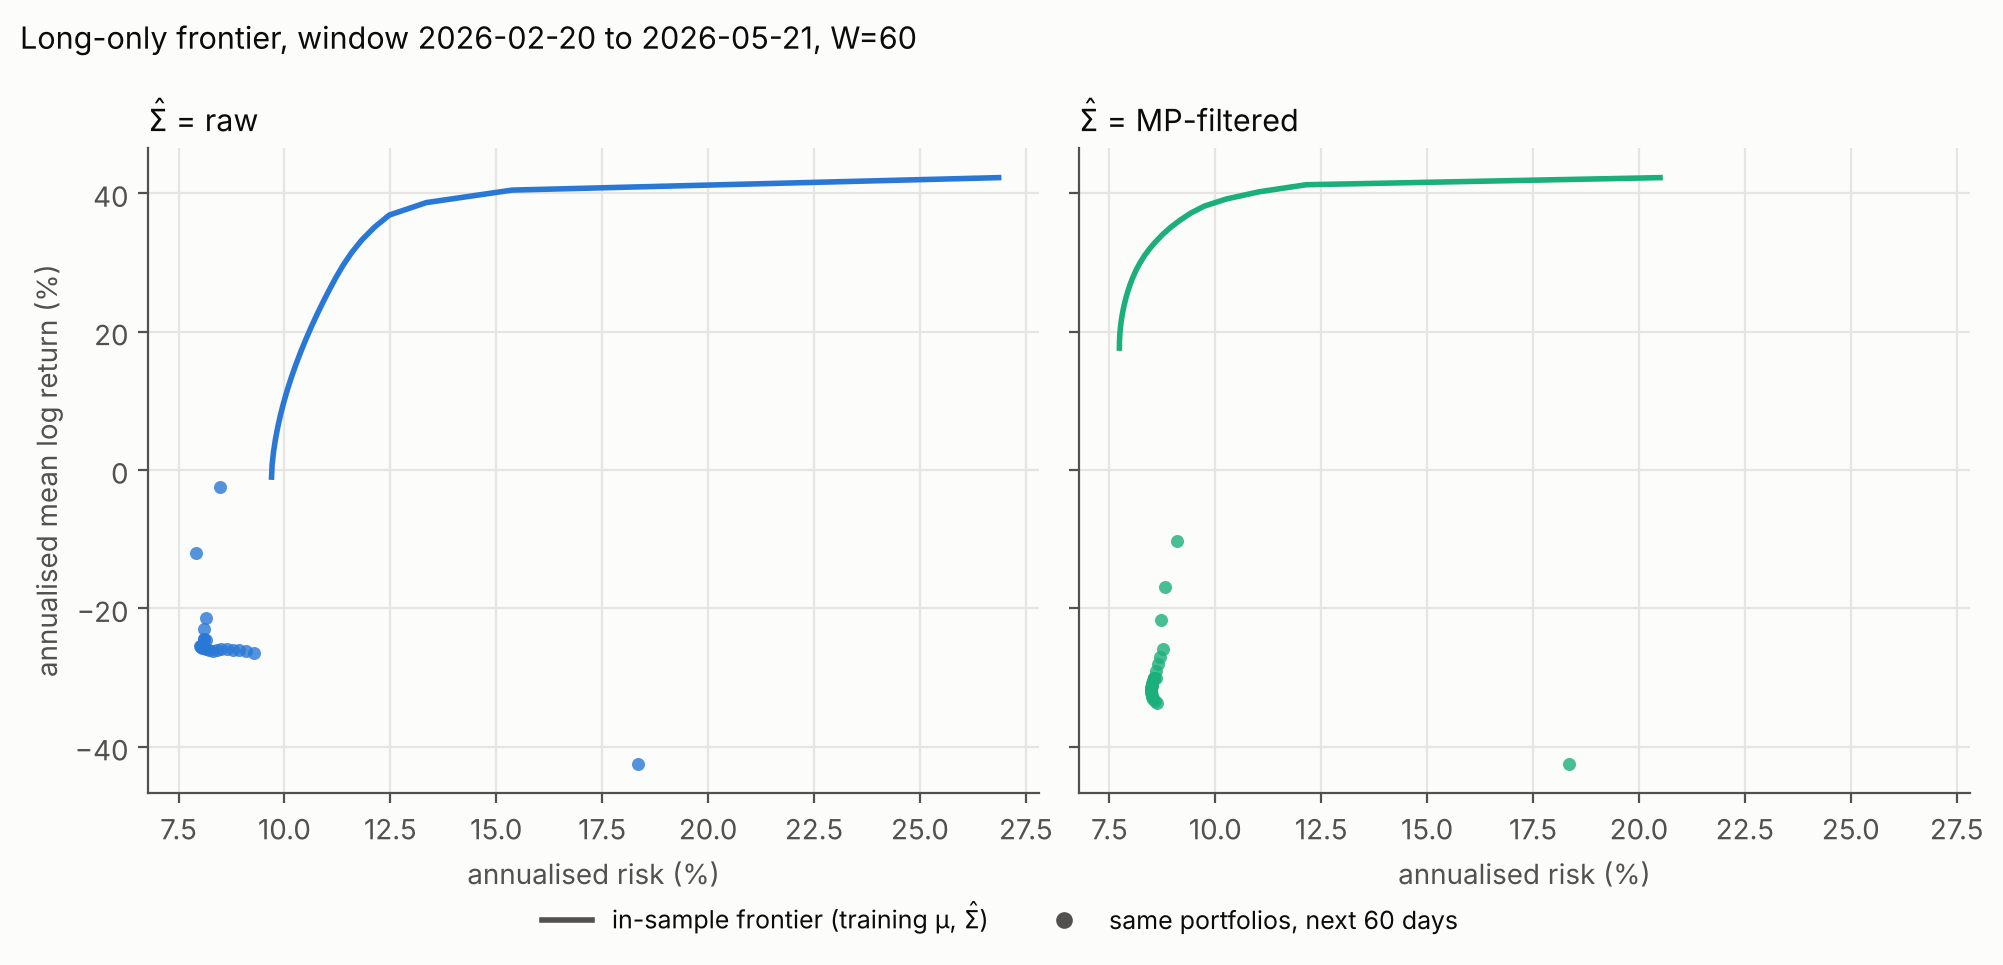

**fig3_weight_comparison.png**

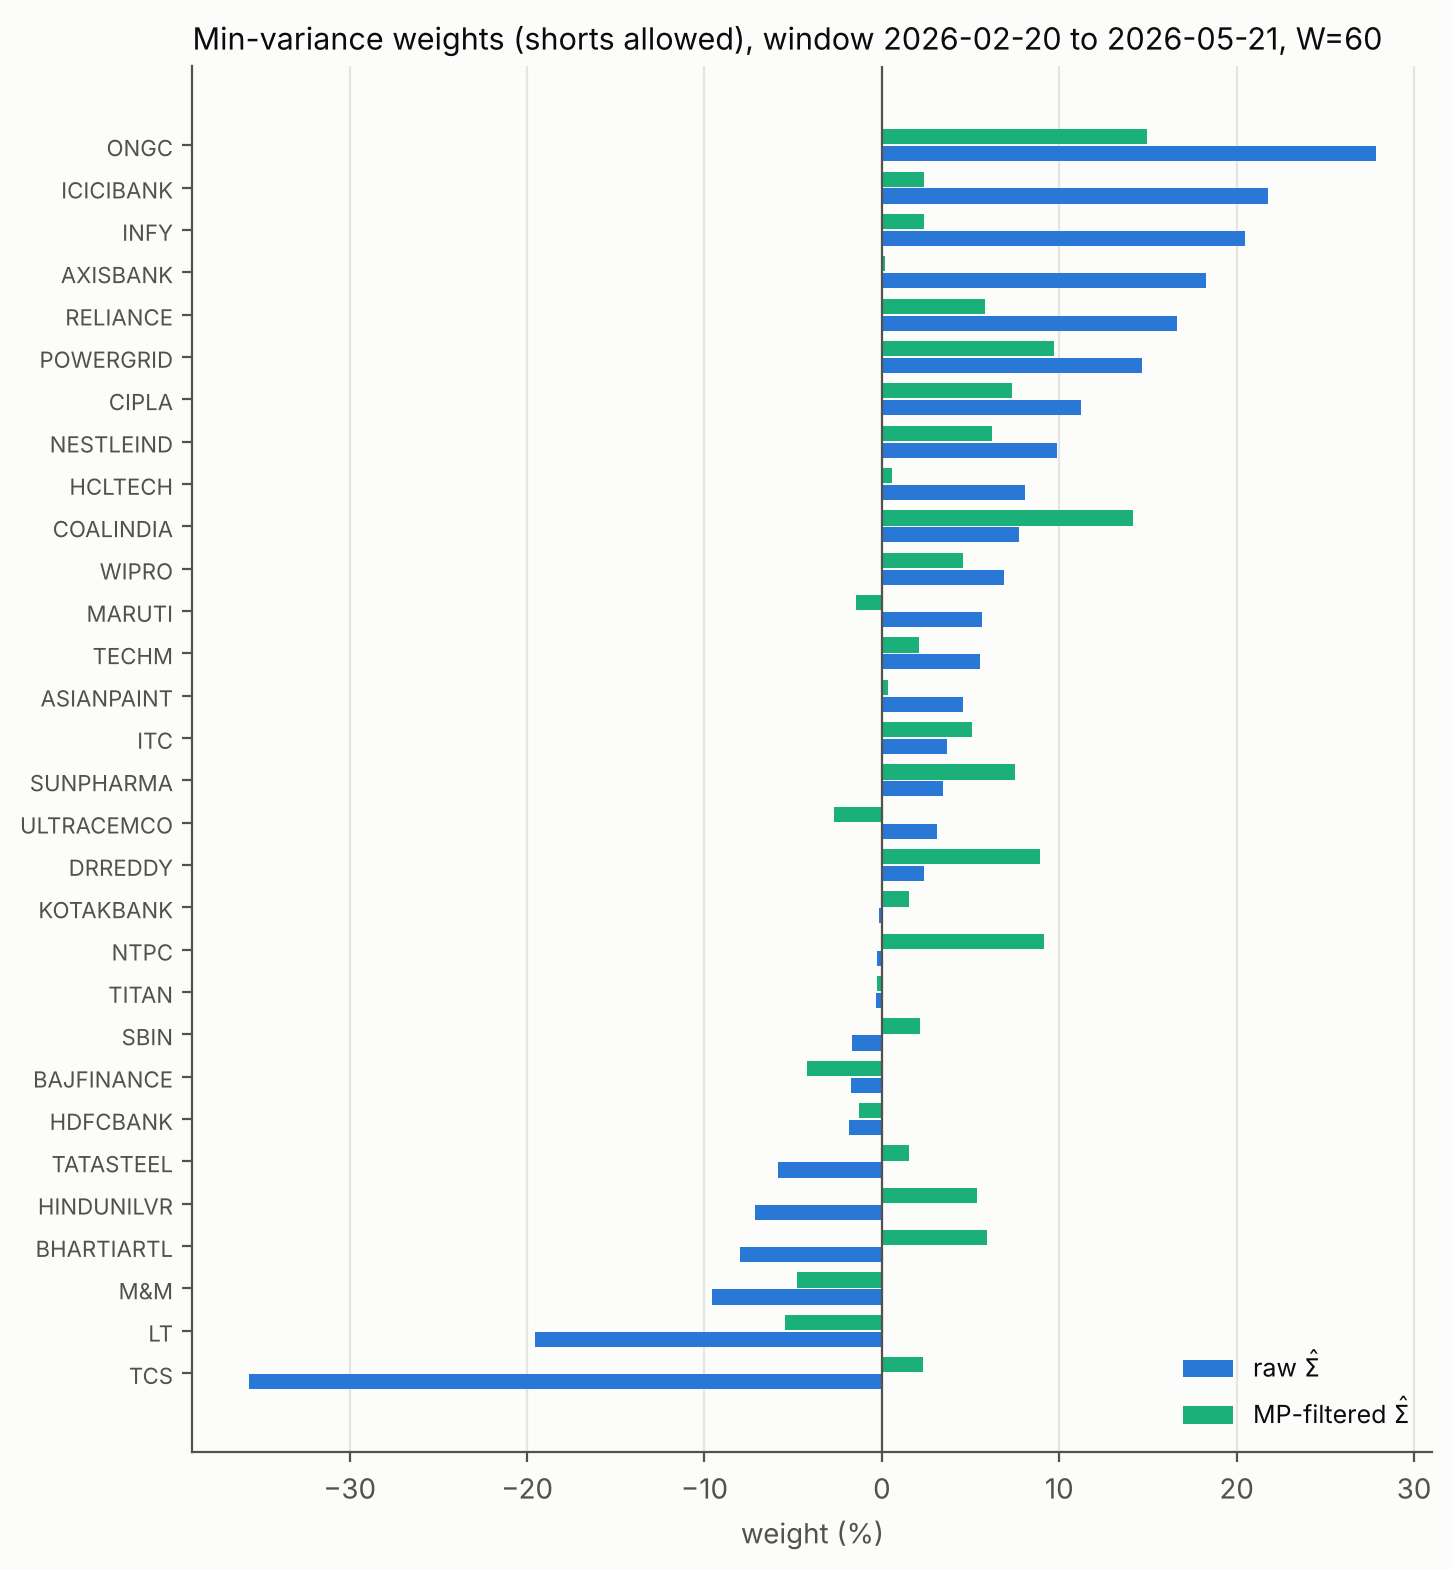

**fig4_risk_contribution.png**

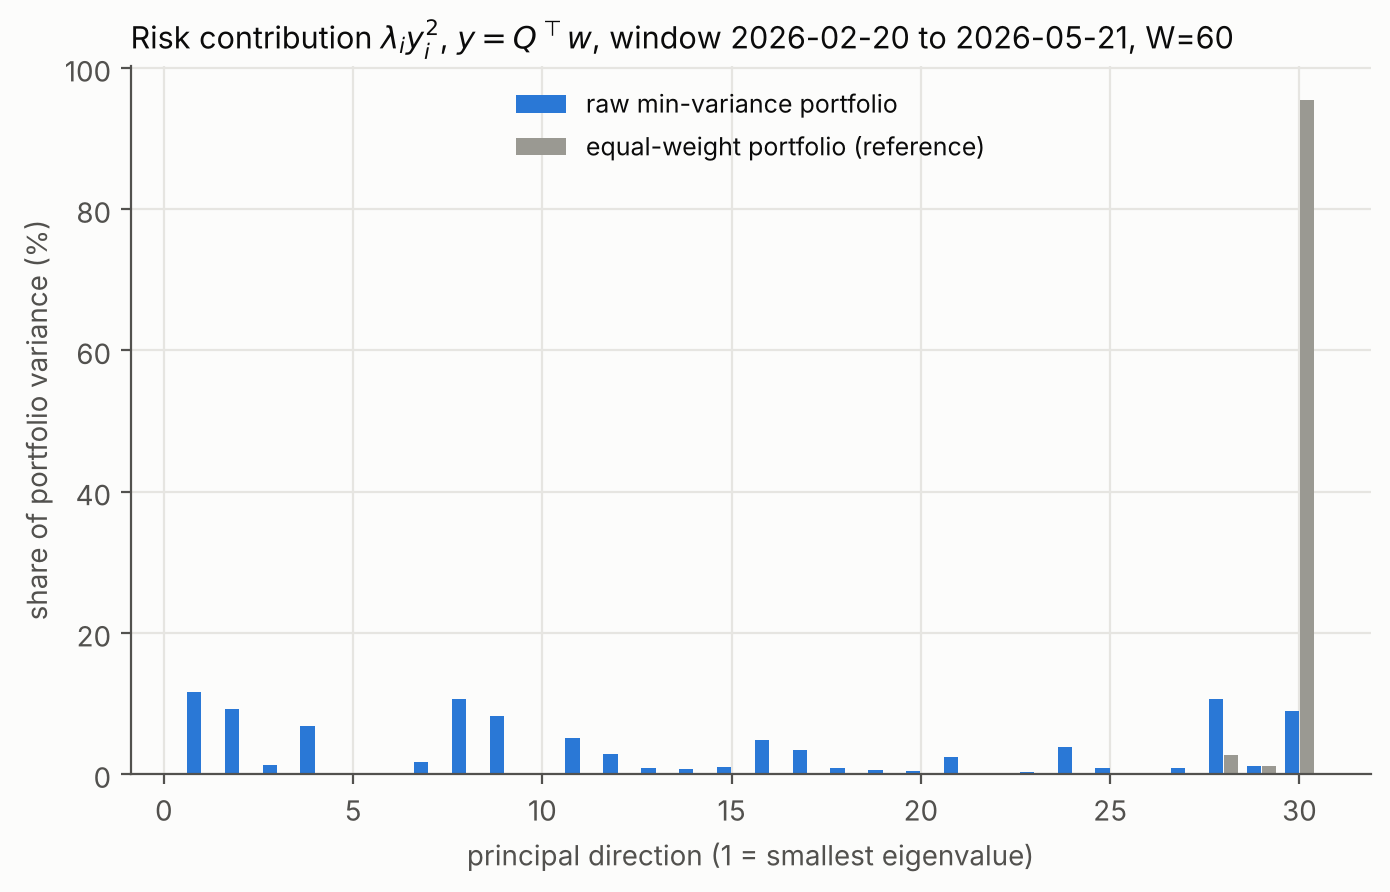

**fig5_predicted_vs_realized.png**

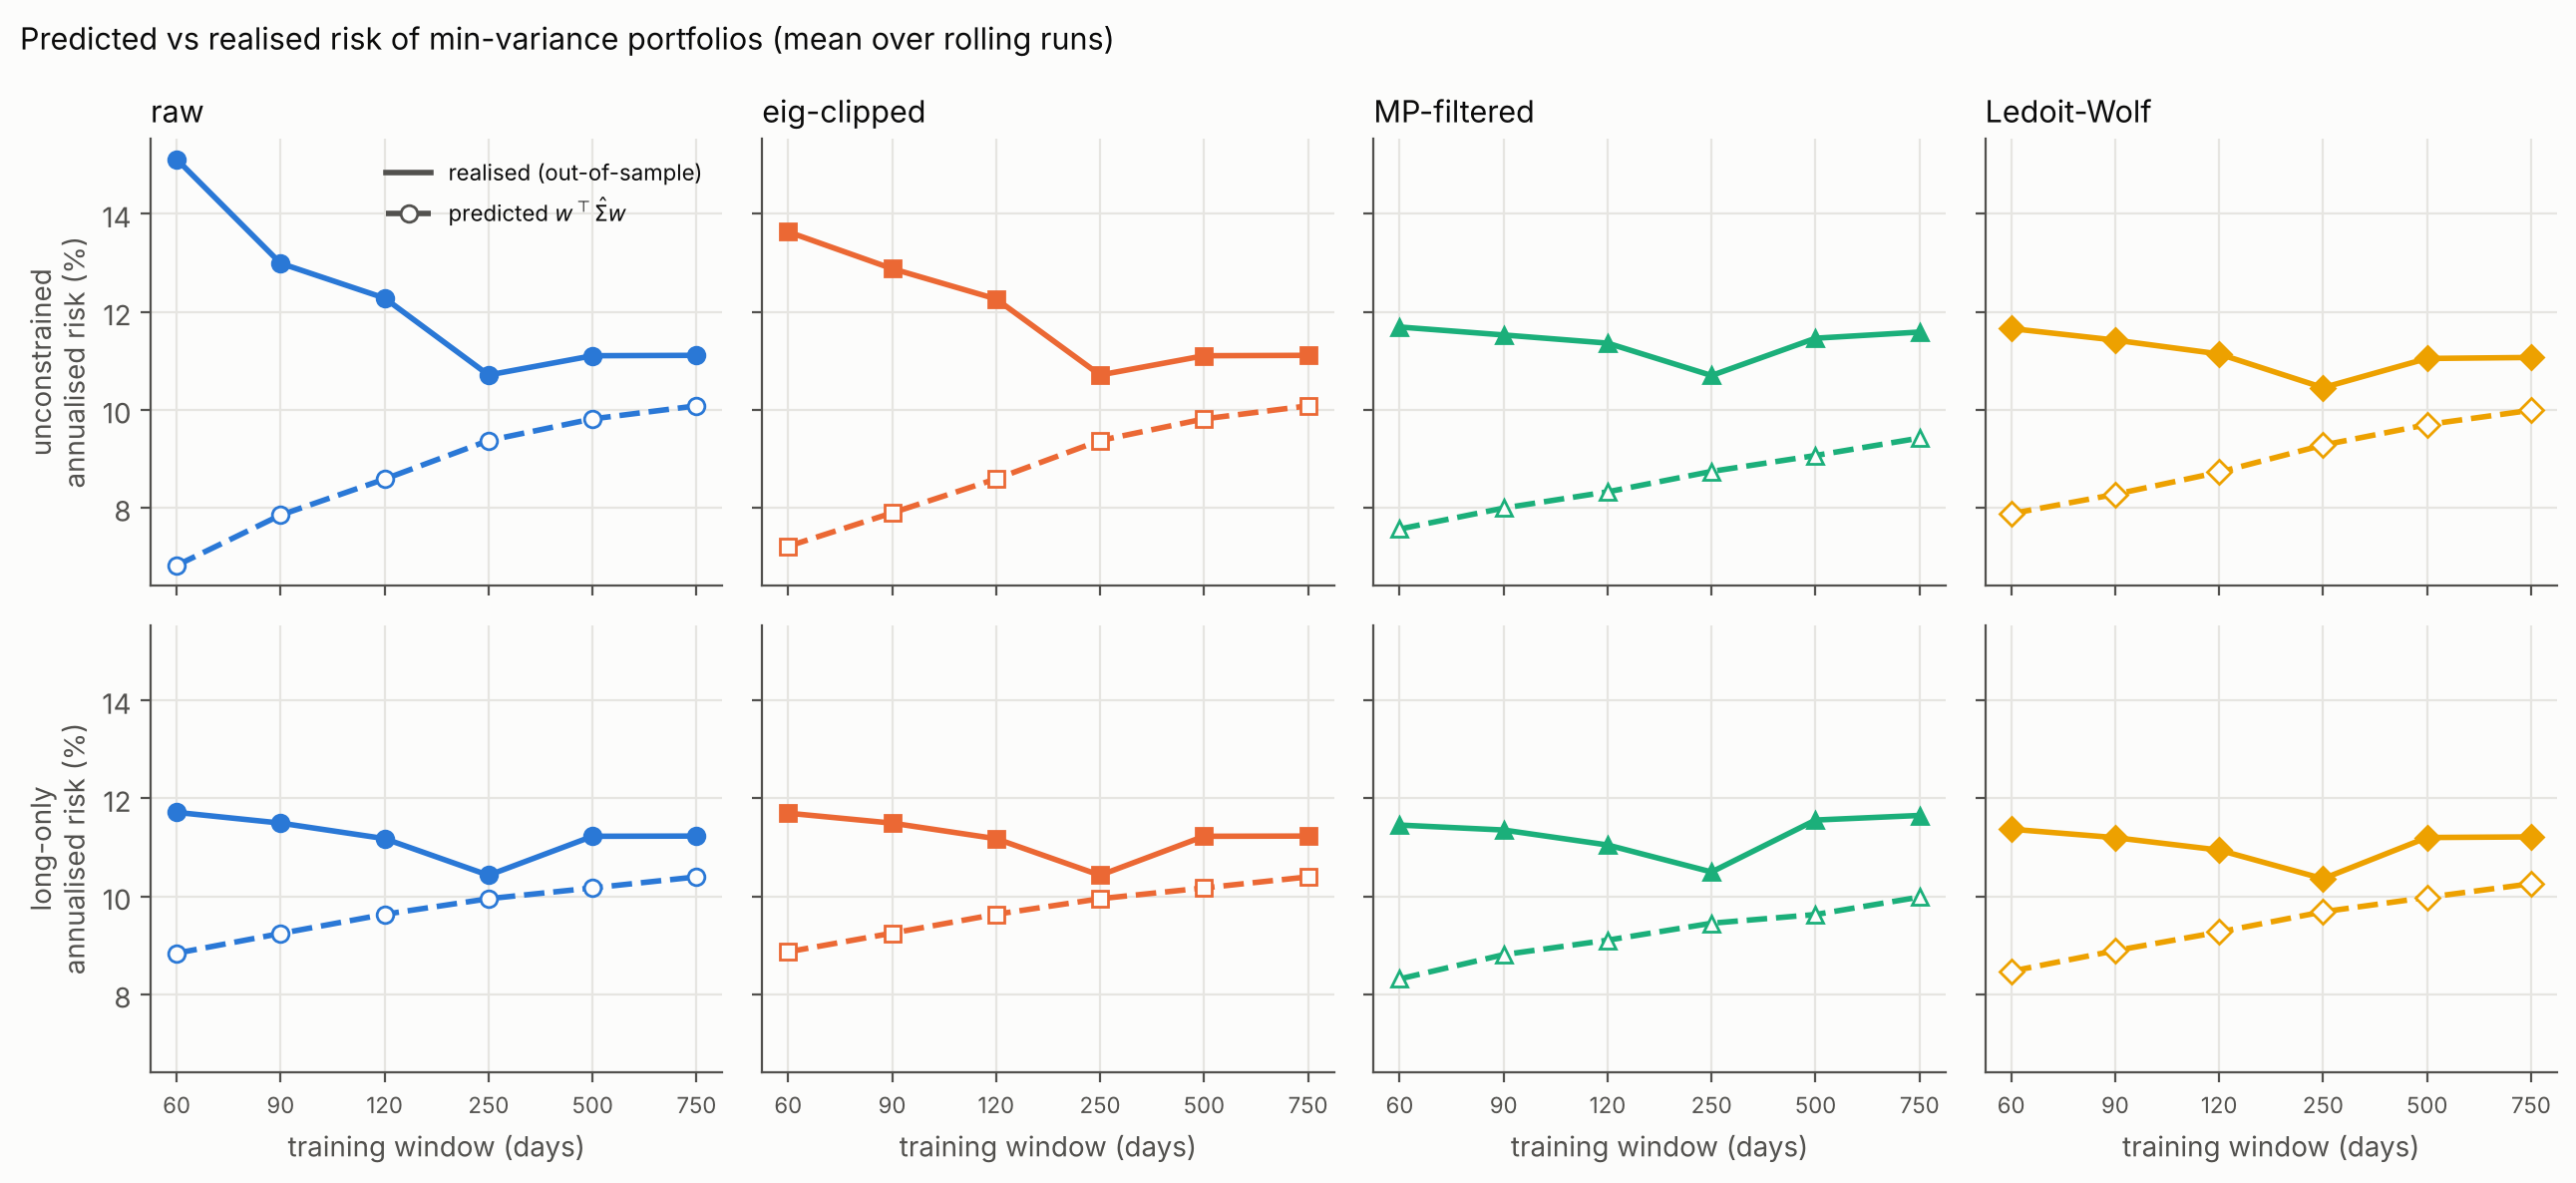

**fig6_exposure_vs_gap_unconstrained.png**

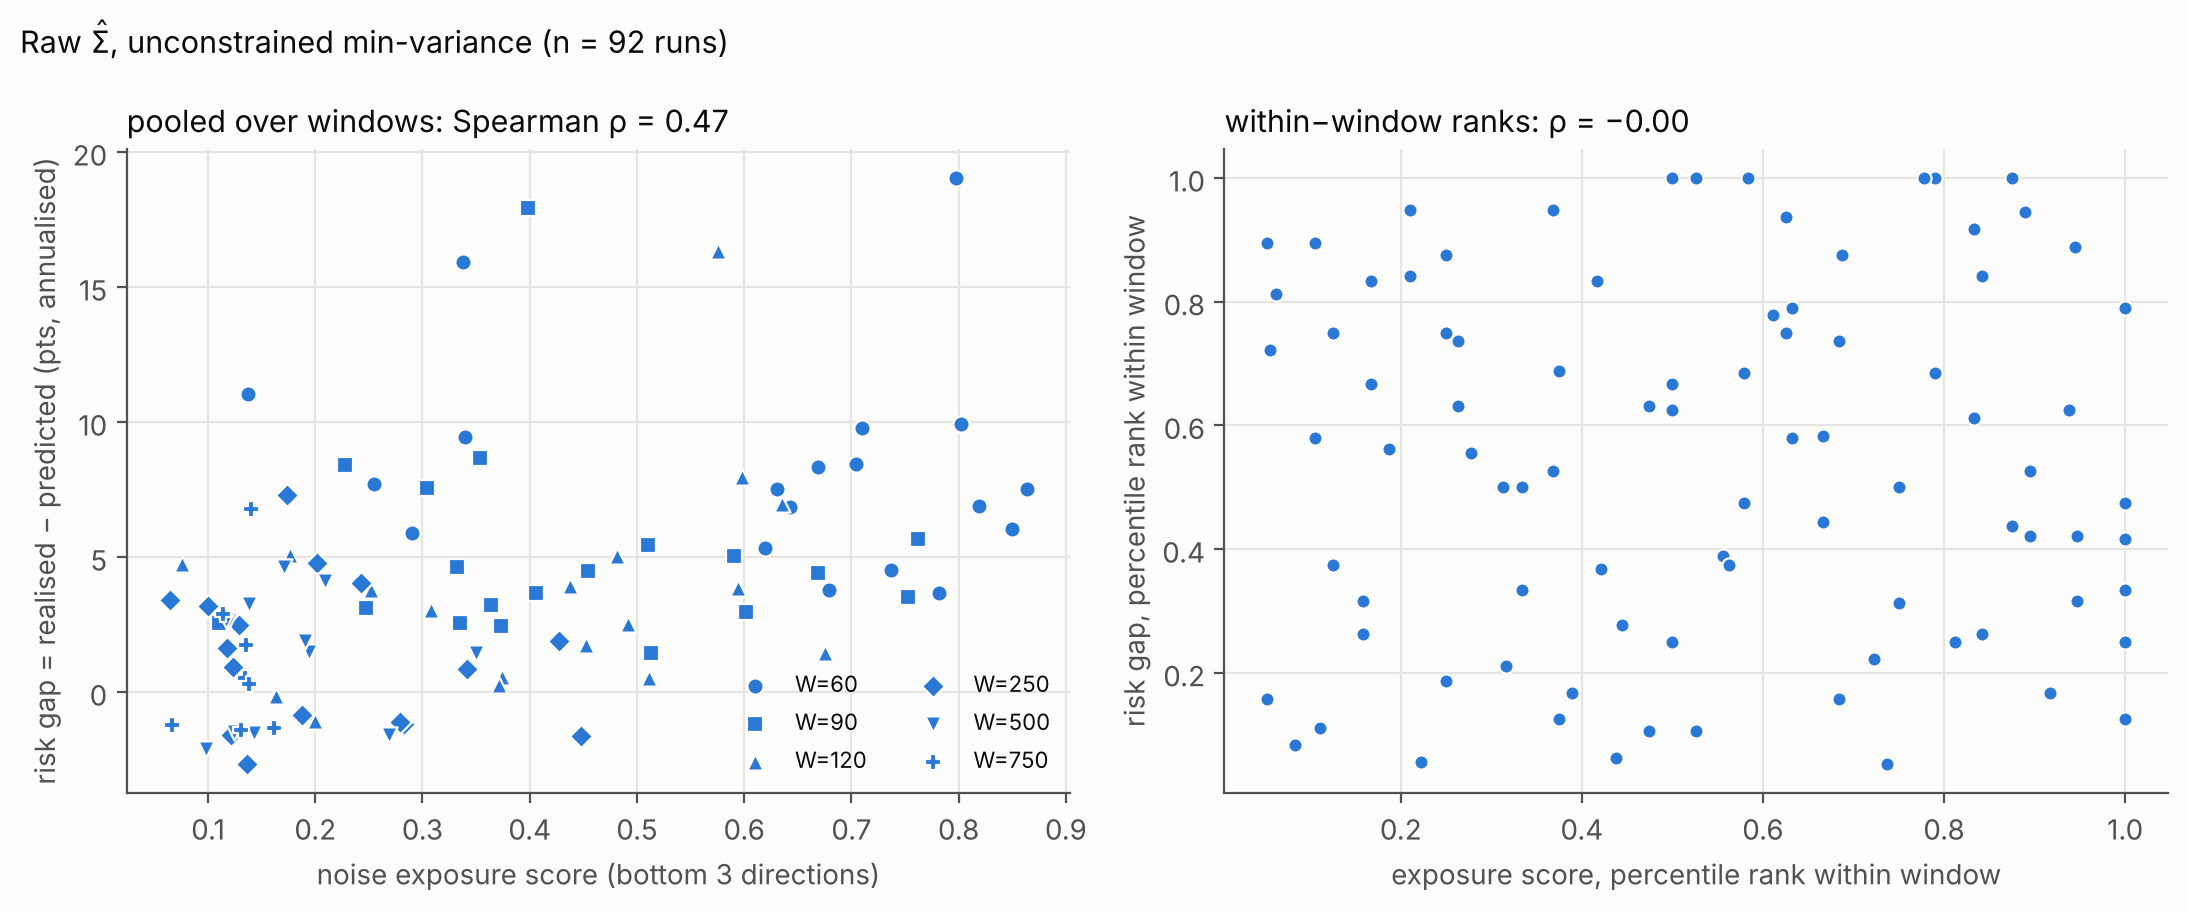

**fig6_exposure_vs_gap_long_only.png**

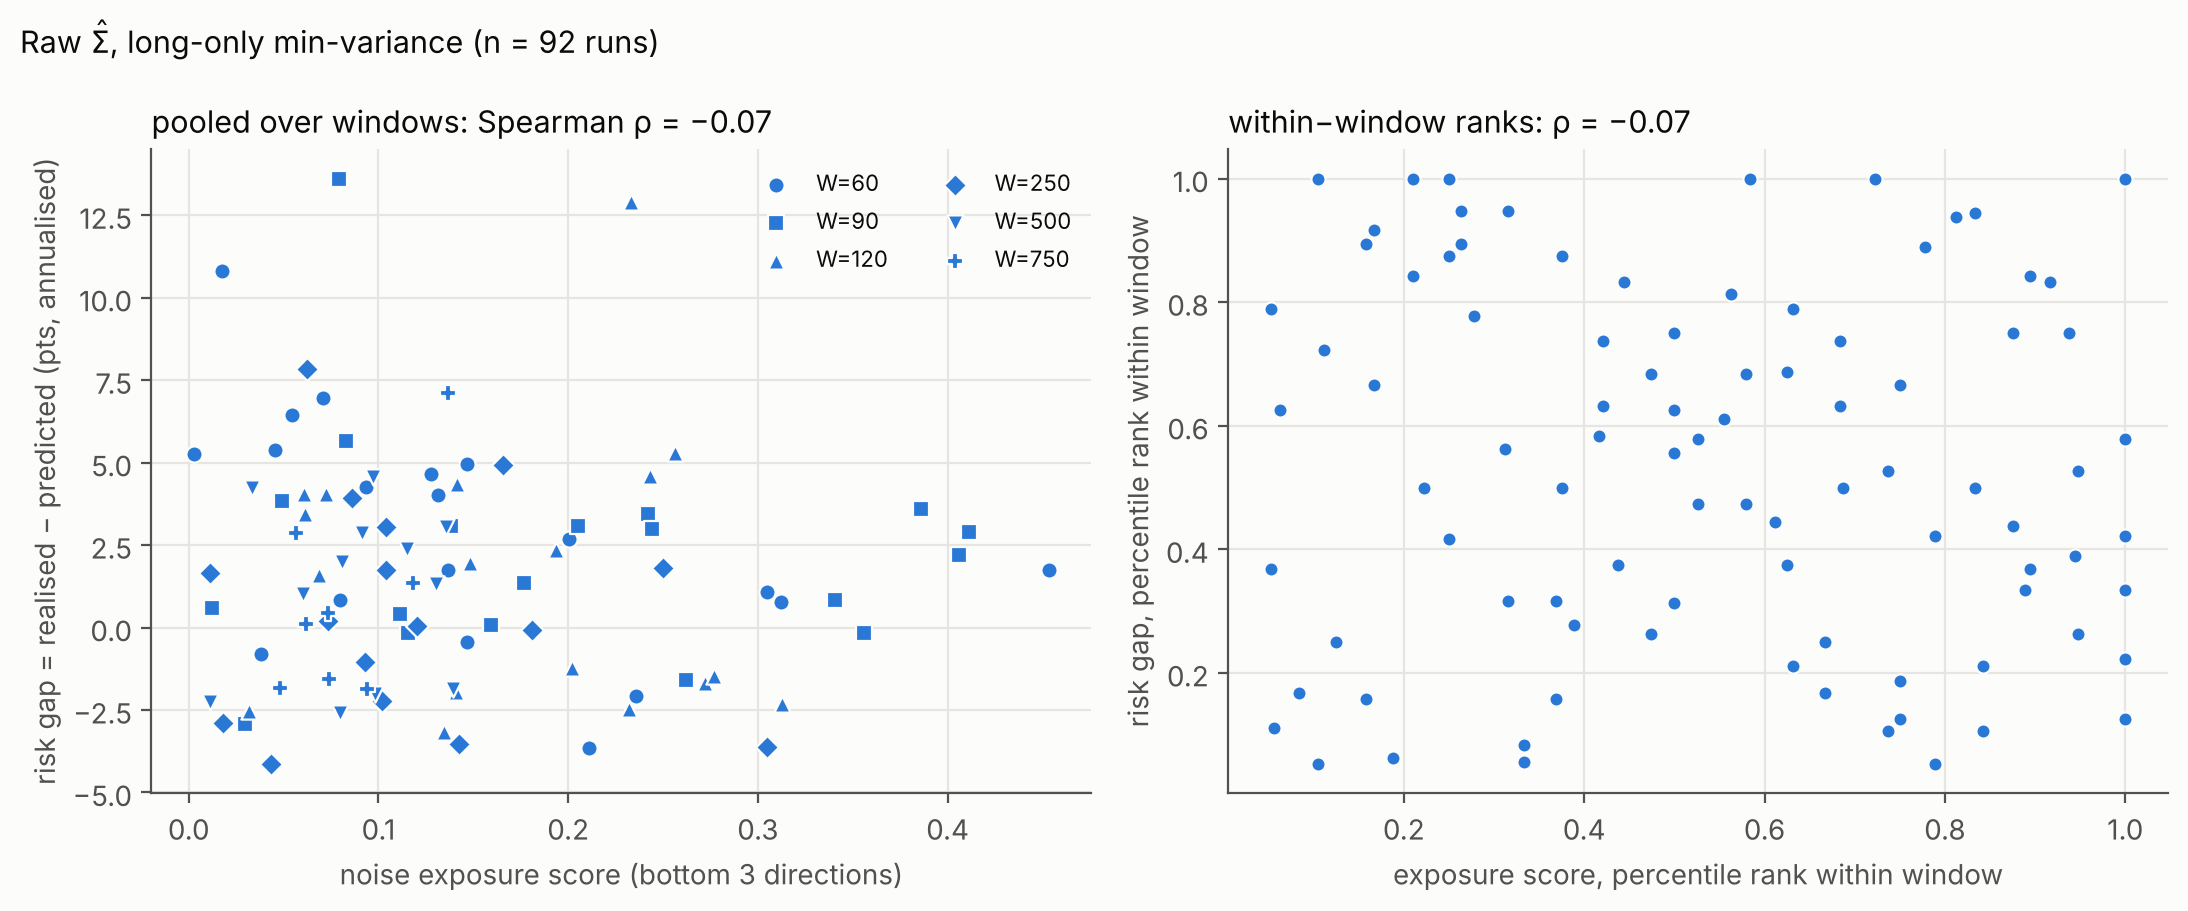

**fig7_condition_number.png**

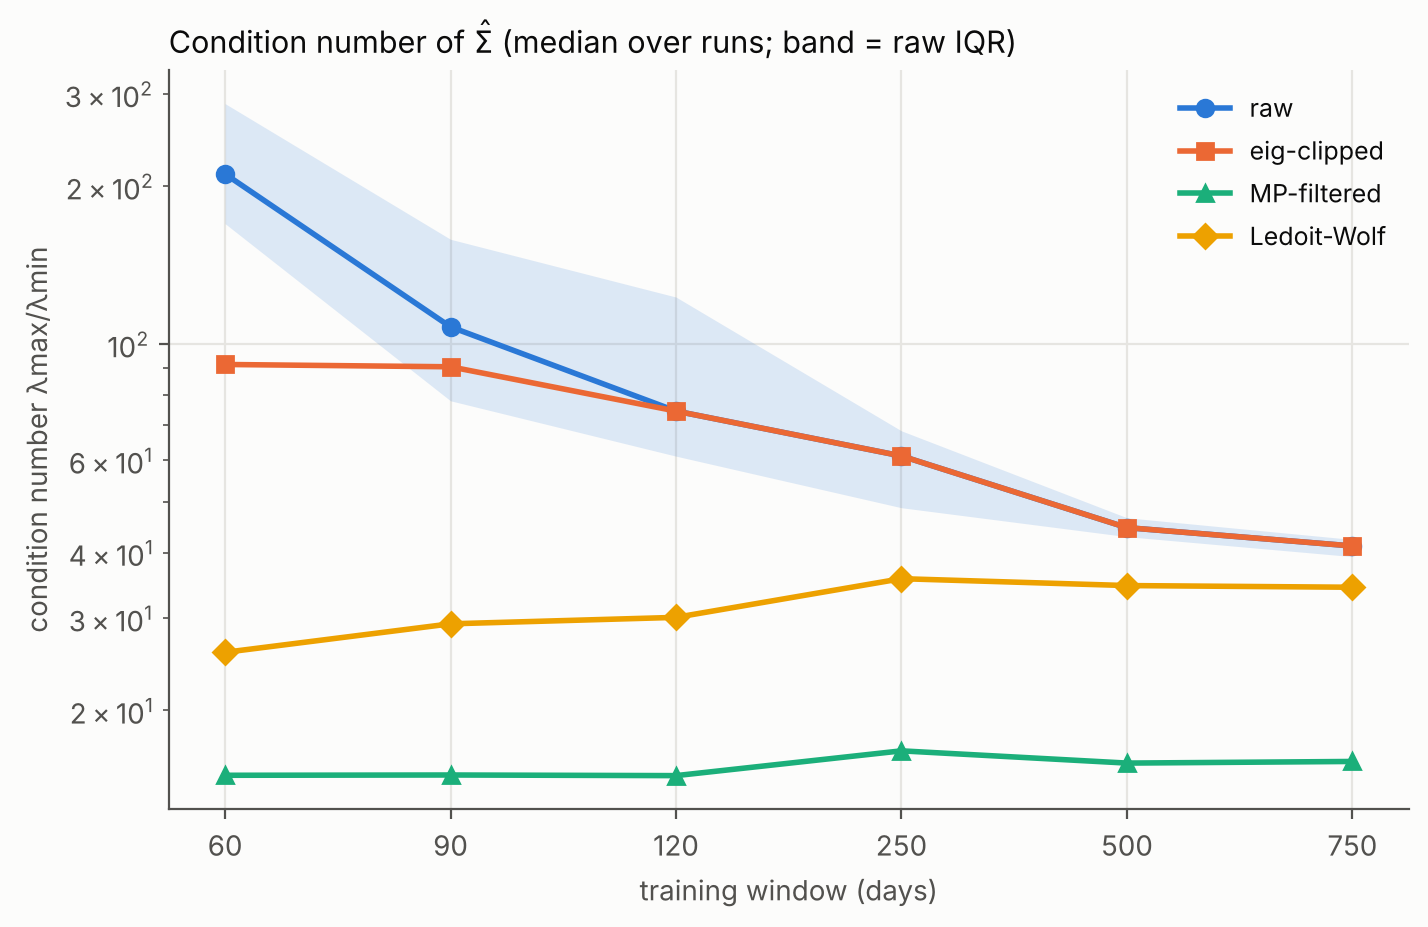

In [9]:
paths = plots.make_all(returns, runs, tables['exposure_vs_gap'], summary)
for p in paths:
    display(Markdown(f'**{p.name}**')); display(Image(filename=str(p), width=900))

## 7. Hypothesis test: does the noise-exposure score predict the risk gap?
`all` pools window lengths (confounded: short windows raise both quantities); `within` ranks inside each window first.

In [10]:
e = tables['exposure_vs_gap']
e[e.window.astype(str).isin(['all','within'])].round(3)

,constraint,k,window,n,spearman_rho,p_value
0,unconstrained,1,all,92,0.262,0.012
7,unconstrained,1,within,92,-0.088,0.406
8,unconstrained,3,all,92,0.470,0.000
15,unconstrained,3,within,92,-0.003,0.977
16,unconstrained,5,all,92,0.586,0.000
23,unconstrained,5,within,92,0.136,0.195
24,long_only,1,all,92,-0.080,0.448
31,long_only,1,within,92,-0.057,0.588
32,long_only,3,all,92,-0.074,0.481
39,long_only,3,within,92,-0.070,0.505


In [11]:
per = e[~e.window.astype(str).isin(['all','within'])]
print(f"{int((per.p_value<0.05).sum())} of {len(per)} per-window tests have unadjusted p<0.05 (about {0.05*len(per):.1f} expected by chance).")
per.pivot_table(index=['constraint','k'], columns='window', values='spearman_rho').round(2)

4 of 36 per-window tests have unadjusted p<0.05 (about 1.8 expected by chance).


window            60    90    120   250   500   750
constraint    k                                    
long_only     1 -0.60 -0.09  0.15  0.10  0.25  0.05
              3 -0.59 -0.03  0.06 -0.01  0.16  0.31
              5 -0.07  0.13  0.37 -0.10  0.32  0.88
unconstrained 1 -0.07 -0.20  0.17 -0.51  0.42 -0.38
              3 -0.16 -0.01  0.32 -0.26  0.05  0.10
              5 -0.01  0.40  0.28 -0.32  0.30  0.19

## 8. Reading the results honestly
* The mechanism is visible directly: the raw min-variance portfolio spreads its risk over the smallest-eigenvalue directions and takes large long/short positions (figures 3–4), and its in-sample risk estimate is too optimistic at short windows (figure 5).
* Repairing Σ (MP filtering, Ledoit-Wolf) or constraining weights to be long-only narrows the gap; the benefit shrinks as the window grows. Eigenvalue clipping with our a-priori floor changes little once $T \gg N$.
* The exposure score is correlated with the gap when windows are pooled, but that correlation is largely a window-length effect; the within-window test is the cleaner one (section 7).
* Limitations (see README): a single 30-stock universe and one sample period, overlapping training windows (p-values optimistic), noisy 60-day realised risk, different out-of-sample periods per window length.
See `results/key_findings.md` for the auto-generated tables.